**Data Engineering HW1**

Ryan Rosu


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')
df.columns

C:\Users\tziga\AppData\Local\Temp\ipykernel_26448\1897947657.py:4: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')


Index(['YEAR', 'CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR',
       'UNIQUE_CARRIER_NAME', 'SERIAL_NUMBER', 'TAIL_NUMBER',
       'AIRCRAFT_STATUS', 'OPERATING_STATUS', 'NUMBER_OF_SEATS',
       'MANUFACTURER', 'AIRCRAFT_TYPE', 'MODEL', 'CAPACITY_IN_POUNDS',
       'ACQUISITION_DATE', 'AIRLINE_ID', 'UNIQUE_CARRIER'],
      dtype='object')

**Problem 1**

CARRIER column

In [203]:
# Investigate CARRIER column
df_carrier_na = df[df['CARRIER'].isna()]
print(f'Percent of missing from CARRIER column: {(df_carrier_na.shape[0] / df.shape[0]) * 100:.2f}%')
print(df_carrier_na[['CARRIER', 'CARRIER_NAME', 'UNIQUE_CARRIER']].head(10))
print(df_carrier_na['CARRIER_NAME'].unique())

print('Possible CARRIER values for North American Airlines:')
print(df[df['CARRIER_NAME'] == 'North American Airlines']['CARRIER'].unique())


Percent of missing from CARRIER column: 0.04%
      CARRIER             CARRIER_NAME UNIQUE_CARRIER
11776     NaN  North American Airlines            NaN
11777     NaN  North American Airlines            NaN
11778     NaN  North American Airlines            NaN
11779     NaN  North American Airlines            NaN
11780     NaN  North American Airlines            NaN
11781     NaN  North American Airlines            NaN
11782     NaN  North American Airlines            NaN
11783     NaN  North American Airlines            NaN
11784     NaN  North American Airlines            NaN
11785     NaN  North American Airlines            NaN
['North American Airlines']
Possible CARRIER values for North American Airlines:
[nan 'NA ']


In [204]:
# Impute missing values in CARRIER
def impute_carrier(df):
    df.loc[df['CARRIER_NAME'] == 'North American Airlines', 'CARRIER'] = 'NA '
impute_carrier(df)
print(f'Percent of missing from CARRIER column after imputation: {(df["CARRIER"].isna().sum() / df.shape[0]) * 100:.2f}%')

Percent of missing from CARRIER column after imputation: 0.00%


CARRIER_NAME column

In [205]:
# Investigate CARRIER_NAME column
df_carrier_name_na = df[df['CARRIER_NAME'].isna()]
print(f'Percent of missing from CARRIER_NAME column: {(df_carrier_name_na.shape[0] / df.shape[0]) * 100:.2f}%')
print(df_carrier_name_na[['CARRIER', 'CARRIER_NAME', 'UNIQUE_CARRIER']].head(10))
print(df_carrier_name_na['CARRIER'].unique())

print('Possible CARRIER_NAME values for L4 :')
print(df[df['CARRIER'] == 'L4']['CARRIER_NAME'].unique())
print('Possible CARRIER_NAME values for OH :')
print(df[df['CARRIER'] == 'OH']['CARRIER_NAME'].unique())

# Check if YEAR resolves ambiguity for OH
print(df_carrier_name_na[df_carrier_name_na['CARRIER'] == 'OH']['YEAR'].unique())
print(df[df['CARRIER'] == 'OH']['YEAR'].unique())
print(df[df['CARRIER'] == 'OH'][df['YEAR'] == 2011]['CARRIER_NAME'].unique())
print(df[df['CARRIER'] == 'OH'][df['YEAR'] == 2013]['CARRIER_NAME'].unique())
print(df[df['CARRIER'] == 'OH'][df['YEAR'] == 2015]['CARRIER_NAME'].unique())

# Check if MANUFACTURER resolves ambiguity for OH
print(df_carrier_name_na[df_carrier_name_na['CARRIER'] == 'OH']['MANUFACTURER'].unique()) # manufacturer is BOMBARDIER INC for all missing CARRIER_NAME values for OH
print(df[df['CARRIER'] == 'OH']['MANUFACTURER'].unique())
pd.crosstab(df[df['CARRIER_NAME'] == 'Comair Inc.']['CARRIER_NAME'], df['MANUFACTURER'])
pd.crosstab(df[df['CARRIER_NAME'] == 'PSA Airlines Inc.']['CARRIER_NAME'], df['MANUFACTURER'])

C:\Users\tziga\AppData\Local\Temp\ipykernel_26448\351704296.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[df['CARRIER'] == 'OH'][df['YEAR'] == 2011]['CARRIER_NAME'].unique())


Percent of missing from CARRIER_NAME column: 0.08%
      CARRIER CARRIER_NAME UNIQUE_CARRIER
11465      L4          NaN            NaN
11466      L4          NaN            NaN
11467      L4          NaN            NaN
11468      L4          NaN            NaN
11469      L4          NaN            NaN
11470      L4          NaN            NaN
11471      L4          NaN            NaN
11472      L4          NaN            NaN
54610      OH          NaN            NaN
54611      OH          NaN            NaN
['L4' 'OH']
Possible CARRIER_NAME values for L4 :
[nan 'Lynx Aviation d/b/a Frontier Airlines']
Possible CARRIER_NAME values for OH :
['Comair Inc.' nan 'PSA Airlines Inc.']
[2013]
[2006 2007 2008 2010 2011 2013 2015 2016 2017 2018 2019 2020 2021 2022
 2023]
['Comair Inc.']
[nan]
['PSA Airlines Inc.']
['BOMBARDIER']
['CANADAIR' 'BOMBARDIER' 'GE' 'Bombardier']


C:\Users\tziga\AppData\Local\Temp\ipykernel_26448\351704296.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[df['CARRIER'] == 'OH'][df['YEAR'] == 2013]['CARRIER_NAME'].unique())
C:\Users\tziga\AppData\Local\Temp\ipykernel_26448\351704296.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[df['CARRIER'] == 'OH'][df['YEAR'] == 2015]['CARRIER_NAME'].unique())


MANUFACTURER,BOMBARDIER,Bombardier,CANADAIR,CANADAIR,Canadair,GE
CARRIER_NAME,,,,,,
PSA Airlines Inc.,49,180,147,49,98,1110


In [206]:
# Impute missing values in CARRIER_NAME
def impute_carrier_name(df):
    df.loc[df['CARRIER'] == 'L4', 'CARRIER_NAME'] = 'Lynx Aviation d/b/a Frontier Airlines'
impute_carrier_name(df)
print(f'Percent of missing from CARRIER_NAME column after imputation: {(df["CARRIER_NAME"].isna().sum() / df.shape[0]) * 100:.2f}%')

Percent of missing from CARRIER_NAME column after imputation: 0.07%


MANUFACTURE_YEAR column

In [207]:
# Investigate MANUFACTURE_YEAR column
print(df['MANUFACTURE_YEAR'].unique())
df_man_year_na = df[df['MANUFACTURE_YEAR'].isna() | (df['MANUFACTURE_YEAR'] == 0)]
print(f'Percent of missing from MANUFACTURE_YEAR column: {(df_man_year_na.shape[0] / df.shape[0]) * 100:.3f}%')
df_man_year_na.nunique(dropna=False)

# Check if TAIL_NUMBER resolves ambiguity for MANUFACTURE_YEAR
tail_numbers = df_man_year_na['TAIL_NUMBER'].unique()
print(tail_numbers)
matches = df[df['TAIL_NUMBER'].isin(tail_numbers)]
print((matches.groupby('TAIL_NUMBER')['MANUFACTURE_YEAR'].nunique()).unique())

# Check if SERIAL_NUMBER resolves ambiguity for MANUFACTURE_YEAR
serial_numbers = df_man_year_na['SERIAL_NUMBER'].unique()
print(serial_numbers)
matches = df[df['SERIAL_NUMBER'].isin(serial_numbers)]
print((matches.groupby('SERIAL_NUMBER')['MANUFACTURE_YEAR'].nunique()).unique())

[2003. 2004. 2005. 1944. 1945. 1954. 1955. 1956. 1957. 1958. 1976. 1977.
 1978. 1988. 1992. 1997. 1966. 1967. 1968. 1969. 1970. 1971. 1980. 1982.
 1987. 1990. 1991. 1993. 1994. 1995. 1996. 1998. 1999. 2000. 2001. 2002.
 2006. 1979. 1981. 1985. 1975. 1984. 1983. 1986. 1989. 1972. 1973. 1974.
 1965. 1953. 1952. 1959. 2007. 2008. 2009. 1961. 2010.    0. 2011. 2012.
 1964. 2013. 2014. 2015. 1900. 2016. 1942. 2017. 2018. 2019. 2020. 2021.
 1197. 2022.   nan 2756. 2023.]
Percent of missing from MANUFACTURE_YEAR column: 0.039%
['N10061' 'N10062' 'N858FD' 'N859FD' 'N302EV' 'N304EV' 'N303EV' 'N305EV'
 'N513UA' 'N308EV' 'N306EV' 'N307EV' 'N309EV' 'N319KA' 'N321GL' 'N320GL'
 'N311EV' 'N312EV' 'N433UP' 'N580UP' 'N581UP' 'N575UP' 'N253UP' 'N664GT'
 'N655CA' 'N690CA' 'N874UA' 'N875UA' 'N1902U' 'N53441' 'N12003' 'N37507'
 'N37508' 'N37257' 'N37538' 'N17529' 'N2352U']
[1 2 3 4 0]
['0' '53534' '53537' '53554' '53601' '24810' '53567' '53568' '53571'
 '53572' '27177' '32440' '32574' '53569' '53574' '2546

NUMBER_OF_SEATS column

In [208]:
# Investigate NUMBER_OF_SEATS column
print(df['NUMBER_OF_SEATS'].unique())
print(df[df['NUMBER_OF_SEATS'] == 0][['AIRCRAFT_TYPE', 'MODEL']].value_counts().head(10)) # check if 0 values are for cargo planes and not passenger planes
df_seats_na = df[df['NUMBER_OF_SEATS'].isna()]
print(f'Percent of missing from NUMBER_OF_SEATS column: {(df_seats_na.shape[0] / df.shape[0]) * 100:.3f}%')

[ 50.  70.   0.   2.   6.  32. 131. 140. 136. 158. 165. 167.  nan 188.
  87. 180. 148.  72.  56. 127. 112. 124. 111. 144. 120. 172. 160. 150.
 100. 175. 104. 157. 155.  37. 174. 183. 119.  30. 142.  66. 178. 186.
 154.  48.  40.   8.   9. 132. 114. 117. 118. 137. 149. 130. 162. 123.
 189. 190. 134. 126. 128. 173.  59.  34.  44.   7.  33.  21.  78. 110.
 125. 182. 184.  90. 122.  64.  63. 108. 170. 138. 185. 168.  75. 109.
  99. 113. 164.  86. 116.  88.   5.  76.  47. 141.  19.  74. 102. 156.
 176.  92.  13.  10.  14.  12.  16.  18. 163. 146. 129. 179.  11. 147.
 153.   3.  54. 145.  41.  62.  68.  60. 152.  65.  29.   1. 143. 181.
 169. 187. 151.  79.  69.  80.  17.   4.  42. 171. 177.  71. 159.  98.
  15. 107. 166.  58.  94.  22.  20.  46.  23.]
AIRCRAFT_TYPE  MODEL      
4162.0         C-208B         1248
6222.0         757-200         838
               757-24APF       739
4162.0         C-208B/3        676
6262.0         767-34AF        547
6912.0         A300F4-622R     523
7402.0

In [209]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

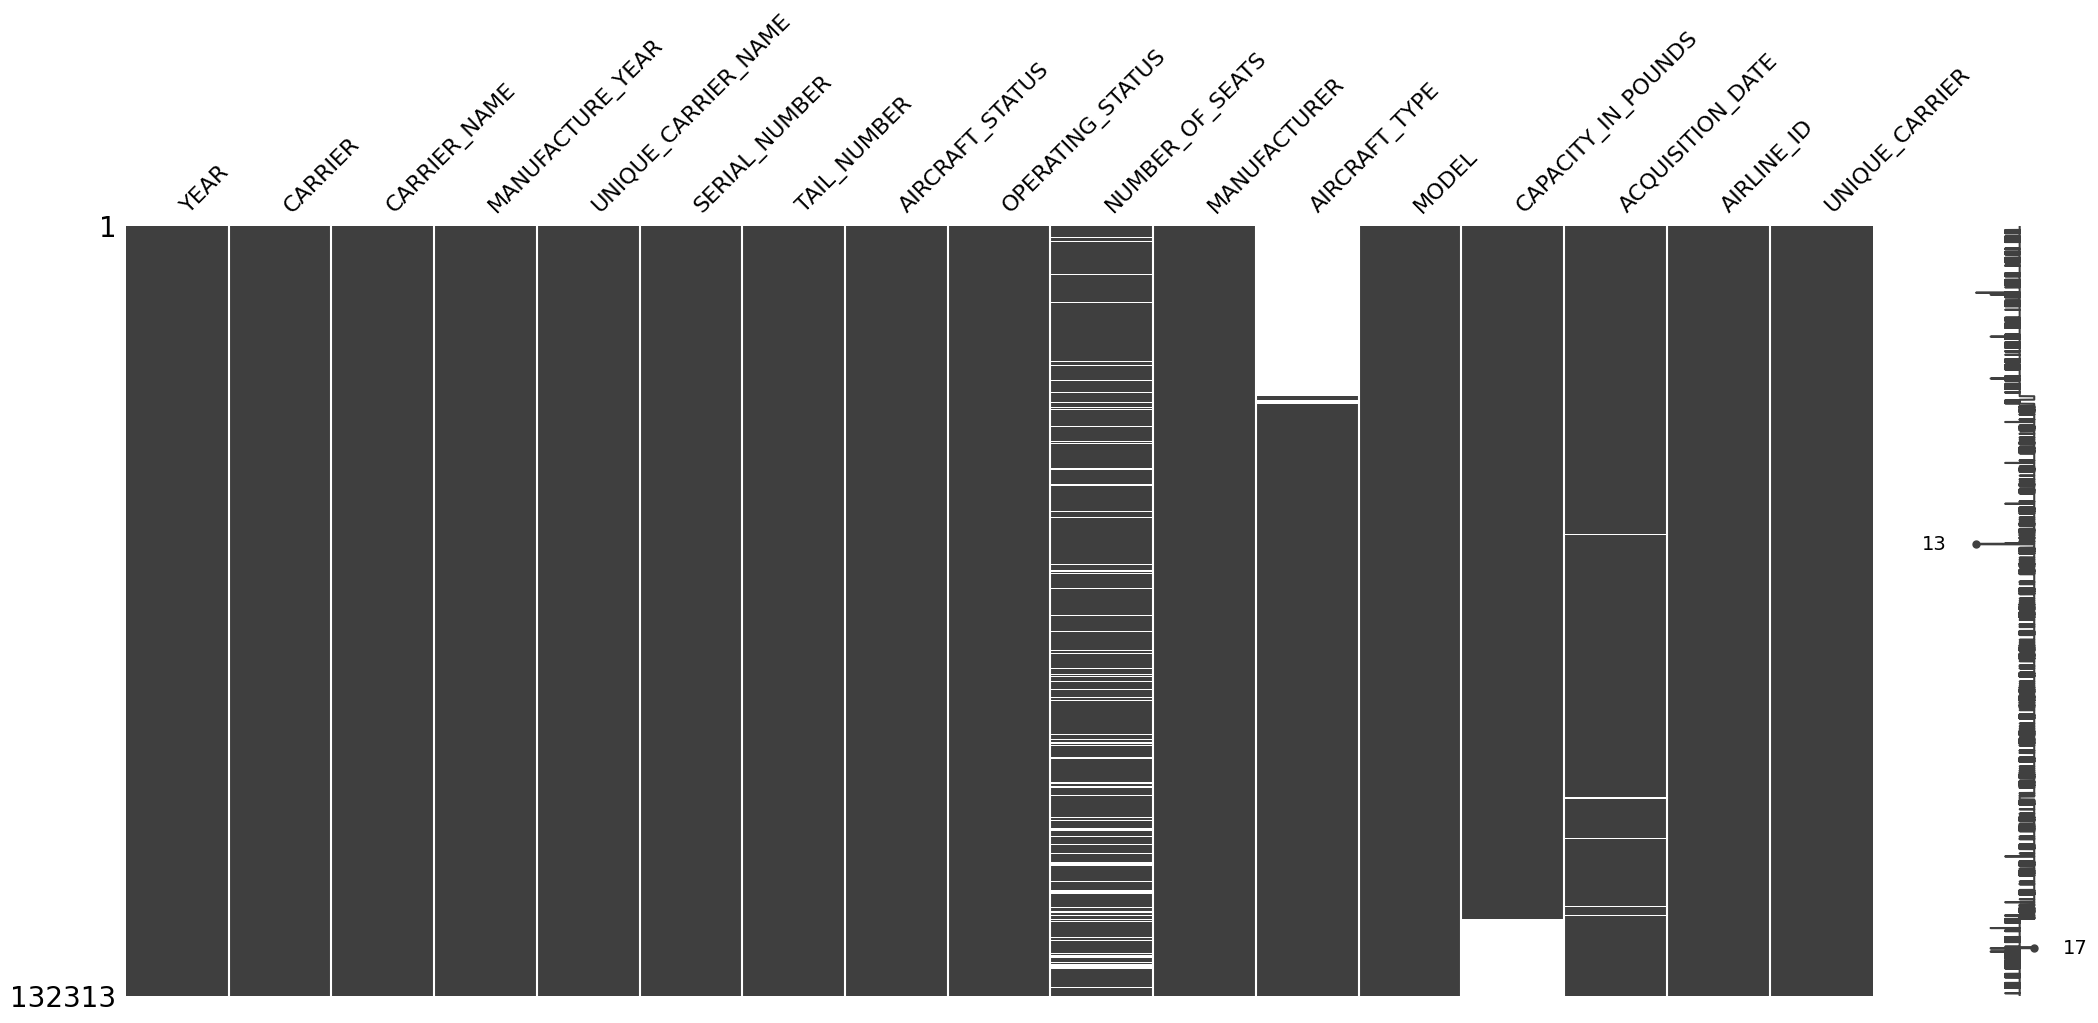

In [210]:
msno.matrix(df)

<Axes: >

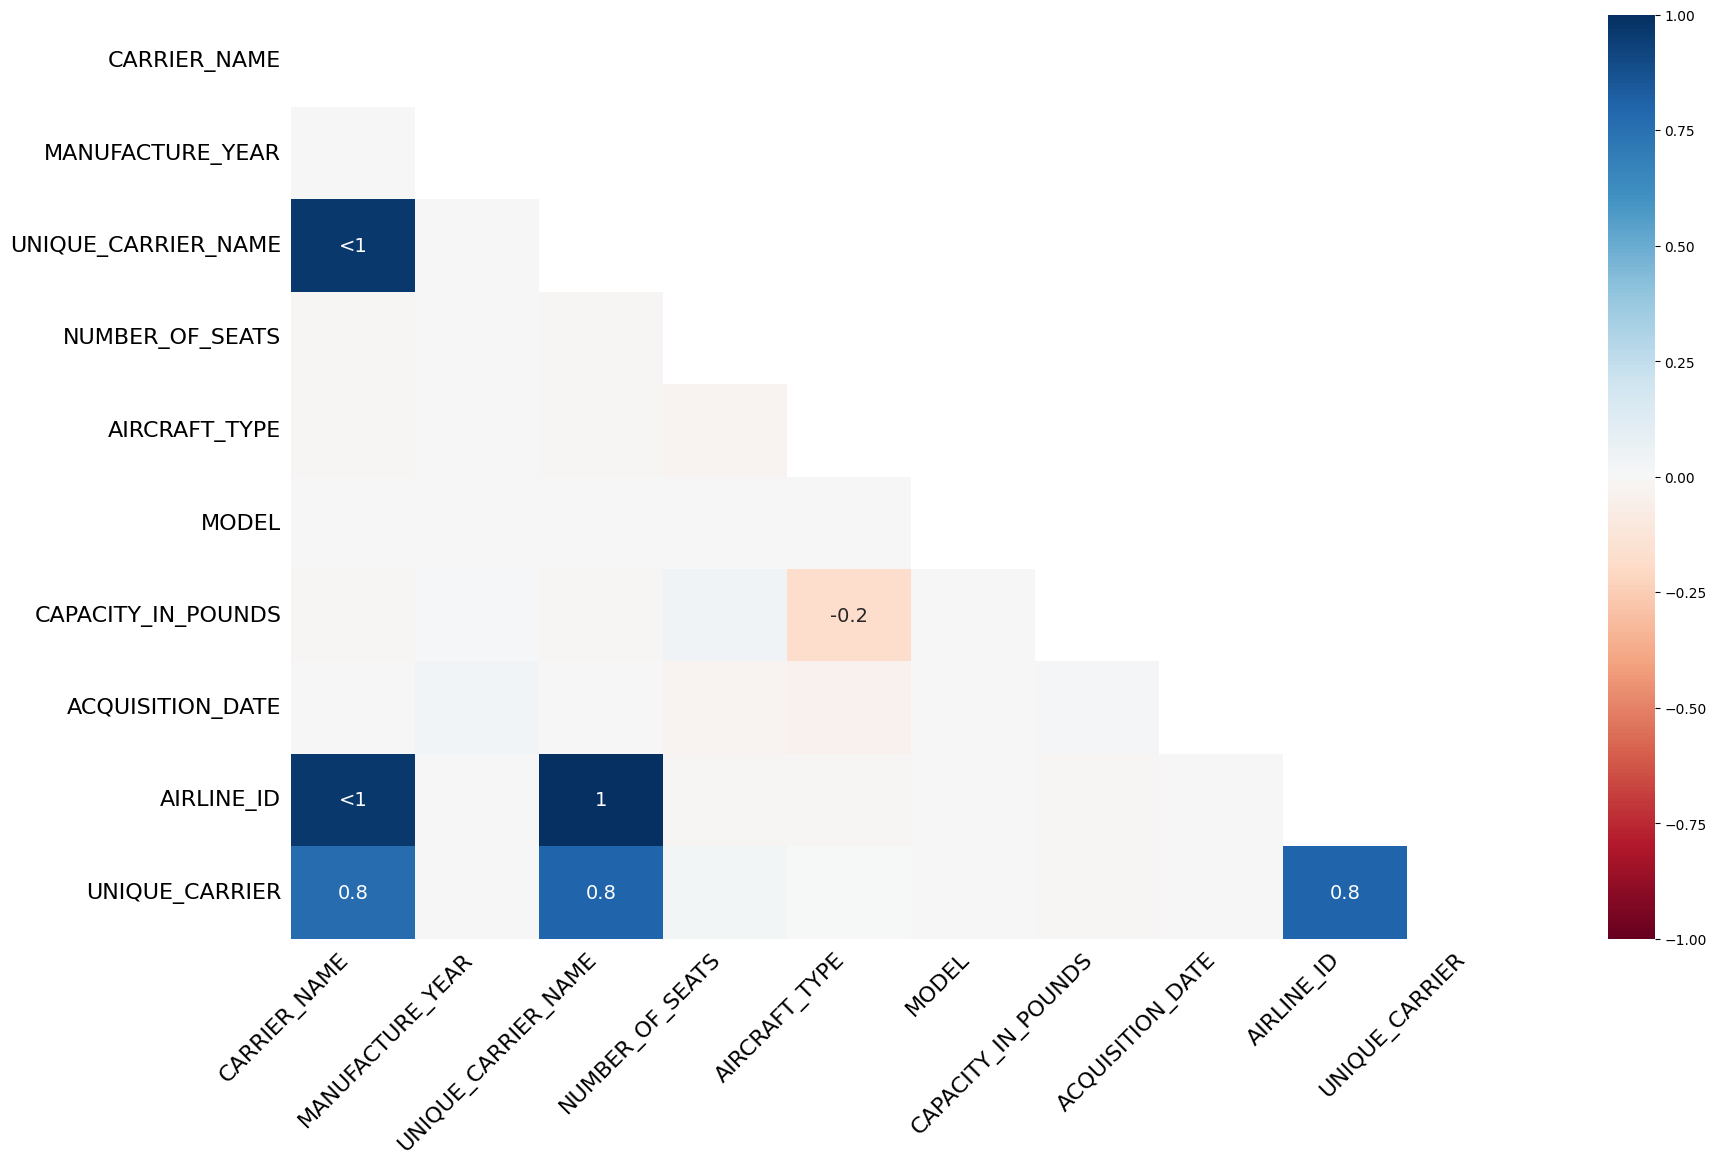

In [211]:
msno.heatmap(df)

<Axes: >

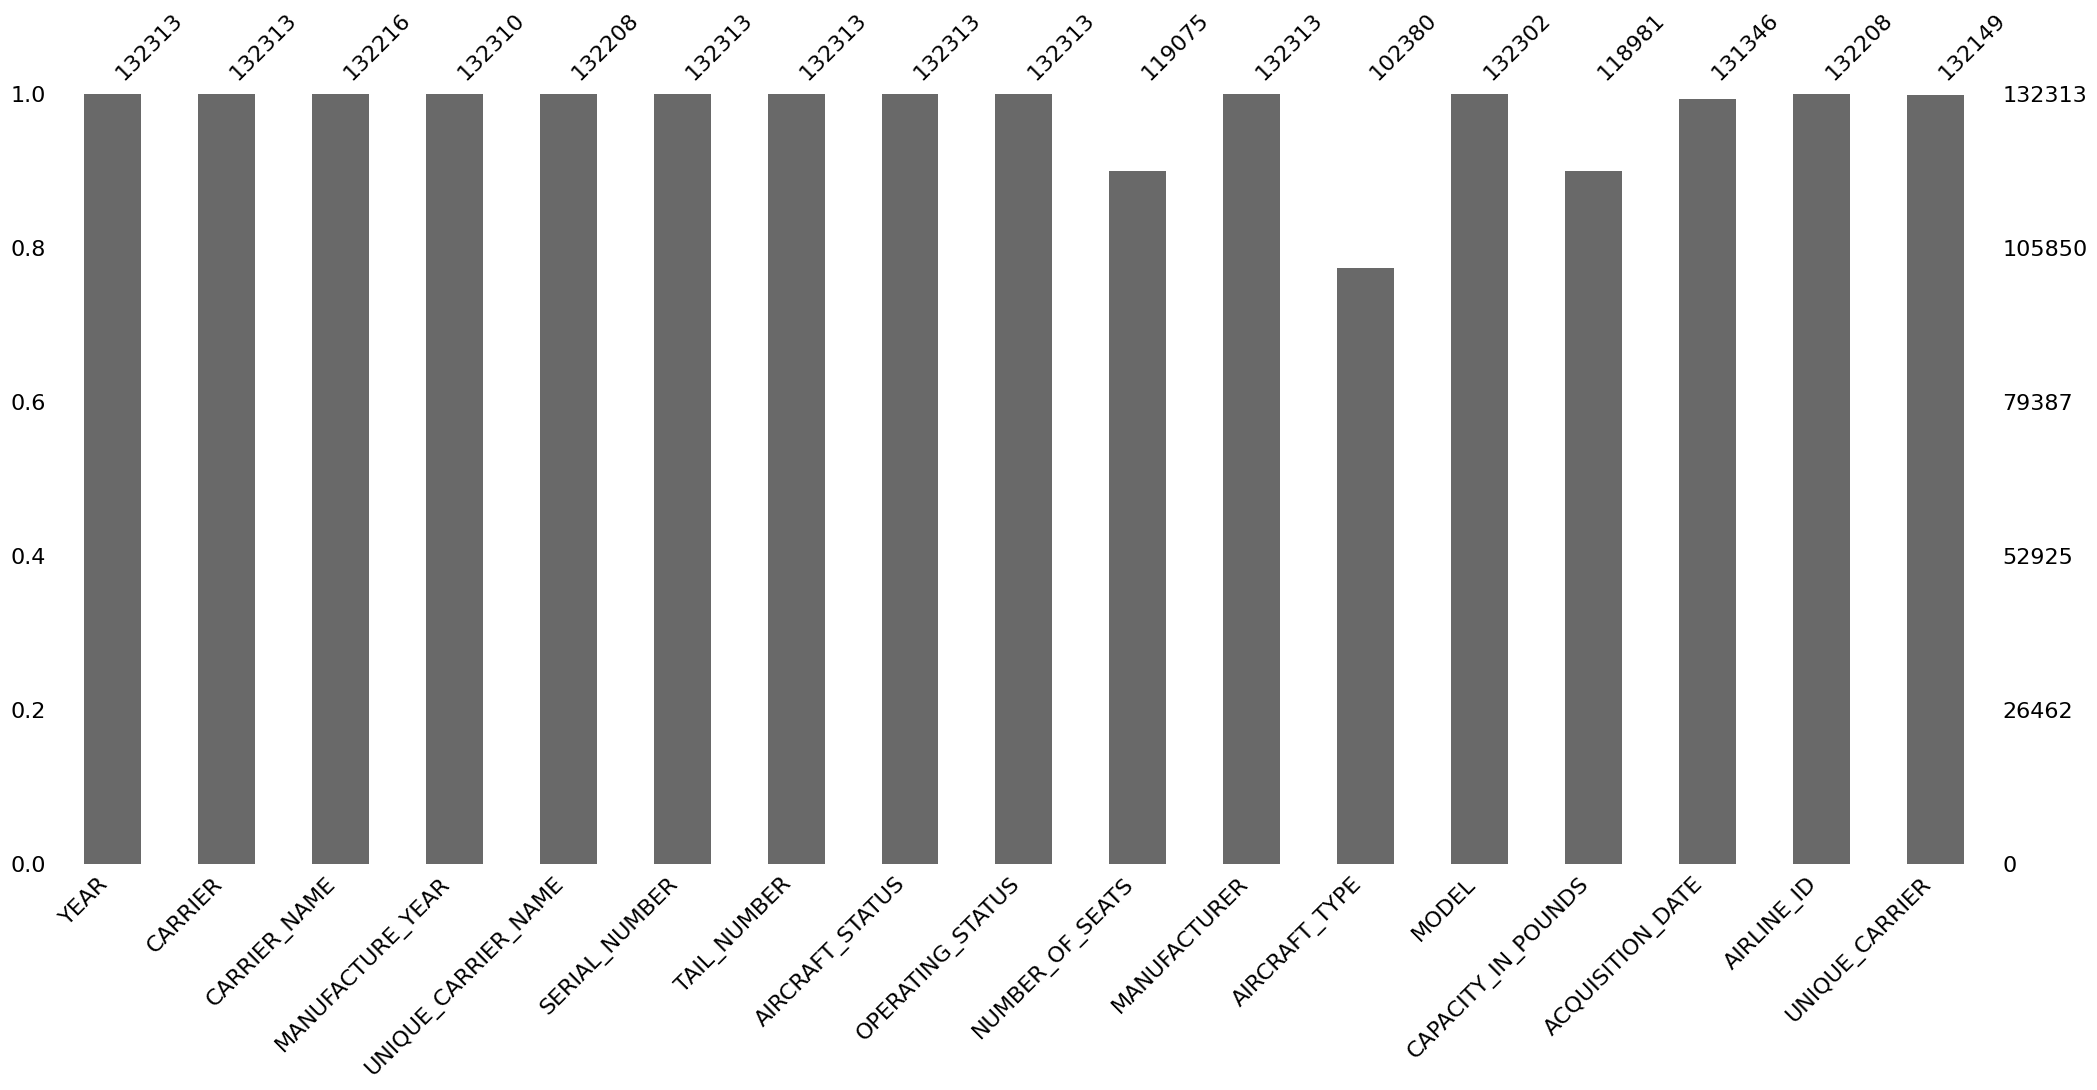

In [212]:
msno.bar(df)

In [213]:
pd.crosstab(df['NUMBER_OF_SEATS'].isna(), df['MODEL'], normalize='columns')

MODEL,0,150,200,2012,208B,318-111,319-111,319-112,320-112,320-114,...,VIRUSSW121C,WESTWIND,WestwindI,WestwindII,a330-200,b717-200,b767-332,b767-33aER,b767-3CbER,b767-3G5ER
NUMBER_OF_SEATS,,,,,,,,,,,,,,,,,,,,,
False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
True,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0


In [214]:
pd.crosstab(df['NUMBER_OF_SEATS'].isna(), df['AIRCRAFT_TYPE'], normalize='columns')

AIRCRAFT_TYPE,323,351,353,413,673,677,793.0,1232.0,1432,1502.0,...,8191,8192,8202,8212,8371,8381,8391,8871,8881,8891
NUMBER_OF_SEATS,,,,,,,,,,,,,,,,,,,,,
False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
True,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.9,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [215]:
# Impute missing values in NUMBER_OF_SEATS
def impute_number_of_seats(df):
    # Use MODEL column to impute
    model_medians = df.groupby('MODEL')['NUMBER_OF_SEATS'].median()
    mask = df['NUMBER_OF_SEATS'].isna()
    df.loc[mask, 'NUMBER_OF_SEATS'] = df.loc[mask, 'MODEL'].map(model_medians)

    # Use AIRCRAFT_TYPE column to impute
    type_medians = df.groupby('AIRCRAFT_TYPE')['NUMBER_OF_SEATS'].median()
    mask = df['NUMBER_OF_SEATS'].isna()
    df.loc[mask, 'NUMBER_OF_SEATS'] = df.loc[mask, 'AIRCRAFT_TYPE'].map(type_medians)
    
    return df

impute_number_of_seats(df)
print(f'Percent of missing from NUMBER_OF_SEATS column after imputation: {(df["NUMBER_OF_SEATS"].isna().sum() / df.shape[0]) * 100:.3f}%')

Percent of missing from NUMBER_OF_SEATS column after imputation: 3.045%


CAPACITY_IN_POUNDS column

In [216]:
# Investigate CAPACITY_IN_POUNDS column
print(df['CAPACITY_IN_POUNDS'].unique())
print(f'Percent of missing values in CAPACITY_IN_POUNDS column: {(df["CAPACITY_IN_POUNDS"].isna().sum() / df.shape[0]) * 100:.3f}%')

[47000. 67000. 14000. ...  2096.  2110.   500.]
Percent of missing values in CAPACITY_IN_POUNDS column: 10.076%


In [217]:
pd.crosstab(df['CAPACITY_IN_POUNDS'].isna(), df['AIRCRAFT_TYPE'], normalize='columns')

AIRCRAFT_TYPE,323,351,353,413,673,677,793.0,1232.0,1432,1502.0,...,8191,8192,8202,8212,8371,8381,8391,8871,8881,8891
CAPACITY_IN_POUNDS,,,,,,,,,,,,,,,,,,,,,
False,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.65,0.60061,0.52,0.668712,0.473684,0.549407,0.490991,0.655367,0.572949,0.625954
True,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.35,0.39939,0.48,0.331288,0.526316,0.450593,0.509009,0.344633,0.427051,0.374046


In [218]:
pd.crosstab(df['CAPACITY_IN_POUNDS'].isna(), df['MODEL'], normalize='columns')

MODEL,0,150,200,2012,208B,318-111,319-111,319-112,320-112,320-114,...,VIRUSSW121C,WESTWIND,WestwindI,WestwindII,a330-200,b717-200,b767-332,b767-33aER,b767-3CbER,b767-3G5ER
CAPACITY_IN_POUNDS,,,,,,,,,,,,,,,,,,,,,
False,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.571429,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
True,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.428571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [219]:
# Impute missing values in CAPACITY_IN_POUNDS
def impute_capacity_in_pounds(df):
    # Use MODEL column to impute
    model_medians = df.groupby('MODEL')['CAPACITY_IN_POUNDS'].median()
    mask = df['CAPACITY_IN_POUNDS'].isna()
    df.loc[mask, 'CAPACITY_IN_POUNDS'] = df.loc[mask, 'MODEL'].map(model_medians)

    # Use AIRCRAFT_TYPE column to impute
    type_medians = df.groupby('AIRCRAFT_TYPE')['CAPACITY_IN_POUNDS'].median()
    mask = df['CAPACITY_IN_POUNDS'].isna()
    df.loc[mask, 'CAPACITY_IN_POUNDS'] = df.loc[mask, 'AIRCRAFT_TYPE'].map(type_medians)
    
    return df

impute_capacity_in_pounds(df)
print(f'Percent of missing values in CAPACITY_IN_POUNDS column after imputation: {(df["CAPACITY_IN_POUNDS"].isna().sum() / df.shape[0]) * 100:.3f}%')

Percent of missing values in CAPACITY_IN_POUNDS column after imputation: 0.077%


AIRLINE_ID column

In [220]:
# Investigate AIRLINE_ID column
print(df['AIRLINE_ID'].unique())
print(f'Percent of missing from AIRLINE_ID column: {(df["AIRLINE_ID"].isna().sum() / df.shape[0]) * 100:.3f}%')
df_airline_id_na = df[df['AIRLINE_ID'].isna()]
print(df_airline_id_na[['AIRLINE_ID', 'CARRIER', 'CARRIER_NAME', 'UNIQUE_CARRIER']].head(10))


print(df_airline_id_na['UNIQUE_CARRIER'].unique())
print(df_airline_id_na['CARRIER'].unique())
print(df_airline_id_na['CARRIER_NAME'].unique())
# df.groupby(u_carriers)['AIRLINE_ID'].nunique()
print(df[df['CARRIER_NAME'] == 'Lynx Aviation d/b/a Frontier Airlines']['AIRLINE_ID'].unique())
print(df[df['CARRIER'] == 'L4']['AIRLINE_ID'].unique())
print(df[df['CARRIER'] == 'OH']['AIRLINE_ID'].unique())

[20397. 20408. 19917. 20007. 19874. 20363. 20190. 19805. 20453. 20354.
 20201. 19678. 19930. 20237. 20409. 19704. 20017. 20093. 19790. 20454.
 20357. 20366. 20450. 20436. 20437. 20107. 20368. 20500. 20166. 21069.
 19690. 19991. 20194. 20370. 20372. 20169. 20151. 20204. 20398. 20405.
 20108. 20416. 19386. 20417. 20304. 20414. 20305. 20177. 20100. 20149.
 20400. 19687. 20344. 19998. 20421. 20422. 20312. 20423. 20447. 19977.
 20355. 20195. 19393. 20095. 20377. 20374. 20170. 20207. 20378. 20314.
 20310. 20046. 21167. 20335. 20057. 20351.    nan 20415. 20452. 20448.
 21177. 21171. 20308. 20254. 20203. 20402. 21217. 21236. 21352. 21402.
 21634. 21161. 21492. 21518. 20418. 21577. 20287. 21631. 21629. 21645.
 21652. 21650. 21712. 21754. 21854. 21875. 21974. 20445. 21979. 20401.
 22085. 22080. 20427.]
Percent of missing from AIRLINE_ID column: 0.079%
       AIRLINE_ID CARRIER                           CARRIER_NAME  \
11465         NaN      L4  Lynx Aviation d/b/a Frontier Airlines   
11466     

In [221]:
# Impute missing values in AIRLINE_ID
def impute_airline_id(df):
    df.loc[df['CARRIER_NAME'] == 'Lynx Aviation d/b/a Frontier Airlines', 'AIRLINE_ID'] = 21217
impute_airline_id(df)
print(f'Percent of missing from AIRLINE_ID column after imputation: {(df["AIRLINE_ID"].isna().sum() / df.shape[0]) * 100:.3f}%')

Percent of missing from AIRLINE_ID column after imputation: 0.073%


**Problem 2**

MANUFACTURER column

In [222]:
# Investigate MANUFACTURER column
a = df['MANUFACTURER'].value_counts()
for manufacturer, count in a.items():
    print(f'{manufacturer}: {count}')

BOEING: 15922
Embraer: 11508
THEBOEINGCO: 9223
Bombardier: 8871
Boeing: 8392
BoeingCo: 7446
AIRBUS: 7179
AirbusIndustries: 6967
BOEINGCOMPANY: 6767
Airbus: 5289
CESSNA: 4157
EMBRAER: 3287
MCDONNELL-DOUGLAS: 3160
BOMBARDIER: 2821
BOEING                                                                          : 2811
MCDONNELLDOUGLAS: 2781
CANADAIR: 2734
AirbusIndustrie: 2666
THEBOEINGCOMPANY: 2142
TheBoeingCompany: 1833
McDonnellDouglas: 1525
GE: 1110
ATR: 1103
Douglas: 990
AIRBUS                                                                          : 963
MCDONNELL-DOUGLAS                                                               : 941
CANADAIR                                                                        : 869
EMBRAER                                                                         : 759
McDonnelDouglas: 736
DeHavilland: 703
BombardierAerospace: 649
BoeingCo.: 584
Gulfstream: 417
BOEINGCO: 355
AirbusCompany: 354
DOUGLASAIRCRAFT: 305
SAAB AIRCRAFT: 290
DEHAVILLAND:

In [223]:
# Standardize MANUFACTURER value case and remove leading/trailing whitespace
df['MANUFACTURER'] = df['MANUFACTURER'].str.strip().str.upper()
a = df['MANUFACTURER'].value_counts()
for manufacturer, count in a.items():
    print(f'{manufacturer}: {count}')

BOEING: 27159
EMBRAER: 15554
AIRBUS: 13440
BOMBARDIER: 11834
THEBOEINGCO: 9231
BOEINGCO: 7801
AIRBUSINDUSTRIES: 7053
BOEINGCOMPANY: 6767
CESSNA: 4514
MCDONNELLDOUGLAS: 4306
MCDONNELL-DOUGLAS: 4159
THEBOEINGCOMPANY: 3975
CANADAIR: 3861
AIRBUSINDUSTRIE: 2666
ATR: 1181
DOUGLAS: 1137
GE: 1110
DEHAVILLAND: 1084
MCDONNELDOUGLAS: 736
BOMBARDIERAEROSPACE: 649
BOEINGCO.: 584
GULFSTREAM: 441
SAAB AIRCRAFT: 411
AIRBUSCOMPANY: 354
DOUGLASAIRCRAFT: 305
CONVAIR: 208
SAAB: 184
LOCKHEED: 158
DASSAULT: 127
BOEING(MCDONNELL-DOUGLAS): 120
DORNIER: 100
MCDO: 99
CURTISS: 46
DASSULT SUD: 45
EASYJET/GOAL: 44
CEBUPACIFIC: 43
PIPER: 36
MCDONNELLDOUGLASMD11-F: 30
EASYJET/GECAS: 30
IBERIA/SMBC: 28
CHALLENGER300: 27
BAE: 26
PILATUS: 24
VUELING/AERCAP: 24
PIPISTRELDOO: 23
AVIANCA/ACG: 21
CASA: 21
SAUDIA/ALAFCO: 20
AEROSPATIALE: 20
FAIRCHILD: 20
MCDONALDDOUGLAS: 19
HAWKER: 19
RAYTHEON: 18
CFMINTERNATIONAL: 17
MDDOUGLAS: 17
ALC/ALASKA: 16
SMBCAVIATIONCAPITALLIMITED: 16
ALITALIA/REALIS: 16
FOKKER: 16
AERCAP: 13
COBAL

In [224]:
# Standardize MANUFACTURER values using mapping
mapping = {
    'THEBOEINGCO': 'BOEING',
    'BOEINGCO': 'BOEING',
    'BOEINGCOMPANY': 'BOEING',
    'THEBOEINGCOMPANY': 'BOEING',
    'BOEINGCO.': 'BOEING',
    'AIRBUSINDUSTRIES': 'AIRBUS',
    'AIRBUSINDUSTRIE': 'AIRBUS',
    'AIRBUSCOMPANY': 'AIRBUS',
    'MCDONNELLDOUGLAS': 'MCDONNELLDOUGLAS',
    'MCDONNELL-DOUGLAS': 'MCDONNELLDOUGLAS',
    'MCDONNELLDOUG': 'MCDONNELLDOUGLAS',
    'MCDONNELL': 'MCDONNELLDOUGLAS',
    'BOMBARDIERAEROSPACE': 'BOMBARDIER'
}

df['MANUFACTURER'] = df['MANUFACTURER'].replace(mapping)


MODEL column

In [225]:
# Investigate MODEL column
print(df['MODEL'].unique().shape)
a = df['MODEL'].value_counts()
for model, count in a.items():
    print(f'{model}: {count}')

(1341,)
EMB-145: 2614
B-737-7H4: 2470
B737-823: 2370
A320-232: 2333
A321-231: 2259
737-700PASSENGERONLY: 2027
C-208B: 1872
B757-2: 1775
CRJ-2/4: 1761
B737-800PAX: 1621
MD-80: 1610
ERJ-170-200LR: 1379
757-200: 1345
CRJ200-2B19: 1342
A319: 1267
B-737-8H4: 1256
CRJ-200: 1148
ERJ-175: 1132
SUPER80PASSENGER: 1108
A320-1/2: 1107
757-24APF: 1039
B737-3: 1036
MD-88-PSGR: 1028
C-208B/3: 1017
MD-11: 991
757-232-PSGR: 988
CRJ-900LR-PSGR: 976
B737-823PASSENGER: 956
B737-8: 951
B737-7/L: 929
CRJ-700: 880
737-832-PSGR: 877
CRJ-200-PSGR: 861
A319-112: 856
B737-900ERPAX: 836
A320: 830
717-200-PSGR: 785
B737-890ALLPAX: 783
767-34AF: 783
EMB-140: 782
CRJ200: 781
CE-208B: 758
CRJ-900-PSGR: 745
E190-100: 735
CRJ700-2C10: 733
A300F4-622R: 731
ERJ-145LR: 721
A-320-PSGR: 710
737-300PASSENGERONLY: 708
0: 706
B767-3: 690
AirbusA320-232: 687
CL65: 682
A321-211: 679
RJ-700: 671
B737-990ERALLPAX: 660
CRJ900: 659
A319-114-PSGR: 627
A320-214: 624
A319-132: 619
MD-11F: 608
CRJ-900: 607
EMB-175-PSGR: 596
B-757-2     

In [226]:
# Standardize MODEL value case and remove leading/trailing whitespace
df['MODEL'] = df['MODEL'].str.strip().str.upper()
print(df['MODEL'].unique().shape)

(1269,)


AIRCRAFT_STATUS column

In [227]:
# Investigate AIRCRAFT_STATUS column
print(df['AIRCRAFT_STATUS'].unique().shape)
a = df['AIRCRAFT_STATUS'].value_counts()
for status, count in a.items():
    print(f'{status}: {count}')


(7,)
O: 79487
b: 30852
B: 12699
a: 7804
A: 1330
L: 122
o: 19


In [228]:
# Standardize AIRCRAFT_STATUS value case
df['AIRCRAFT_STATUS'] = df['AIRCRAFT_STATUS'].str.upper()
print(df['AIRCRAFT_STATUS'].value_counts())

AIRCRAFT_STATUS
O    79506
B    43551
A     9134
L      122
Name: count, dtype: int64


OPERATING_STATUS column


In [229]:
# Investigate OPERATING_STATUS column
print(df['OPERATING_STATUS'].unique().shape)
a = df['OPERATING_STATUS'].value_counts()
for status, count in a.items():
    print(f'{status}: {count}')

(4,)
Y: 126577
N: 5664
y: 71
 : 1


In [230]:
df[df['OPERATING_STATUS'] == ' ']

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
118601,2022,C5,CommuteAir LLC dba CommuteAir,2003.0,CommuteAir LLC dba CommuteAir,145700,N24128,B,,50.0,EMBRAER,6751,EMB-145XR,12755.0,9/1/2020 12:00:00 AM,20445.0,C5


In [231]:
# Standardize AIRCRAFT_STATUS value case and replace empty string value with nan
df['OPERATING_STATUS'] = df['OPERATING_STATUS'].str.upper()
df['OPERATING_STATUS'] = df['OPERATING_STATUS'].replace(' ', np.nan)
print(df['OPERATING_STATUS'].value_counts())

OPERATING_STATUS
Y    126648
N      5664
Name: count, dtype: int64


**Problem 3**

In [232]:
print(df.isna().sum())
df.shape

YEAR                       0
CARRIER                    0
CARRIER_NAME              97
MANUFACTURE_YEAR           3
UNIQUE_CARRIER_NAME      105
SERIAL_NUMBER              0
TAIL_NUMBER                0
AIRCRAFT_STATUS            0
OPERATING_STATUS           1
NUMBER_OF_SEATS         4029
MANUFACTURER               0
AIRCRAFT_TYPE          29933
MODEL                     11
CAPACITY_IN_POUNDS       102
ACQUISITION_DATE         967
AIRLINE_ID                97
UNIQUE_CARRIER           164
dtype: int64


(132313, 17)

In [233]:
df = df.dropna()
df.shape

(98145, 17)

**Problem 4**

NUMBER_OF_SEATS column

In [234]:
import scipy

In [235]:
print(df['NUMBER_OF_SEATS'].skew())

-0.24602643725462064


<Axes: xlabel='NUMBER_OF_SEATS', ylabel='Count'>

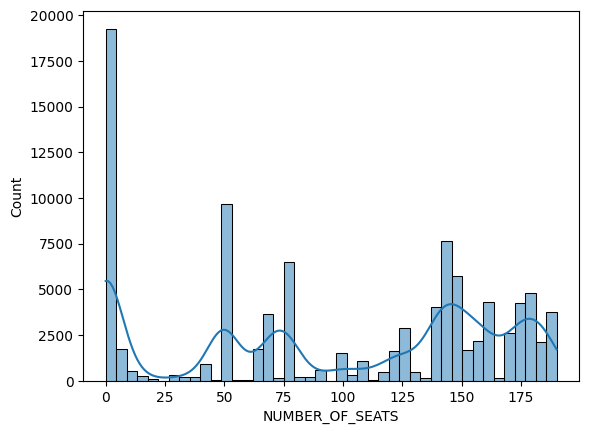

In [236]:
sns.histplot(df['NUMBER_OF_SEATS'], kde=True)

<Axes: xlabel='NUMBER_OF_SEATS_BOXCOX', ylabel='Count'>

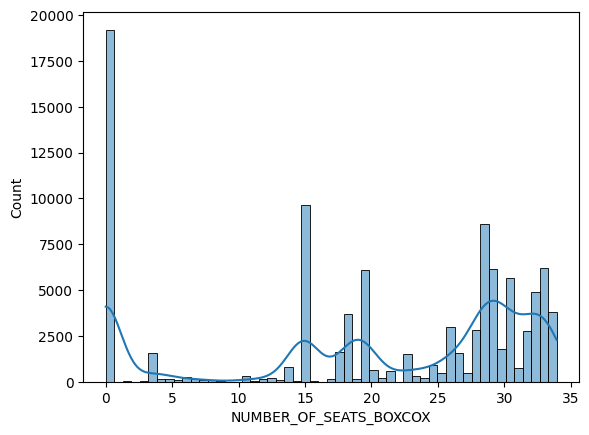

In [237]:
# df[df['NUMBER_OF_SEATS'] < 0].shape
(df['NUMBER_OF_SEATS_BOXCOX'], lam) = scipy.stats.boxcox(df['NUMBER_OF_SEATS']+1)
sns.histplot(df['NUMBER_OF_SEATS_BOXCOX'], kde=True)

In [238]:
print(df['NUMBER_OF_SEATS'].mean())
print(df['NUMBER_OF_SEATS_BOXCOX'].mean())
print(df['NUMBER_OF_SEATS_BOXCOX'].skew())
print(lam)

96.8945845432778
20.082739602557613
-0.6571941123063505
0.5752411338597649


CAPACITY_IN_POUNDS columns

In [239]:
print(df['CAPACITY_IN_POUNDS'].skew())

4.183049620108739


<Axes: xlabel='CAPACITY_IN_POUNDS', ylabel='Count'>

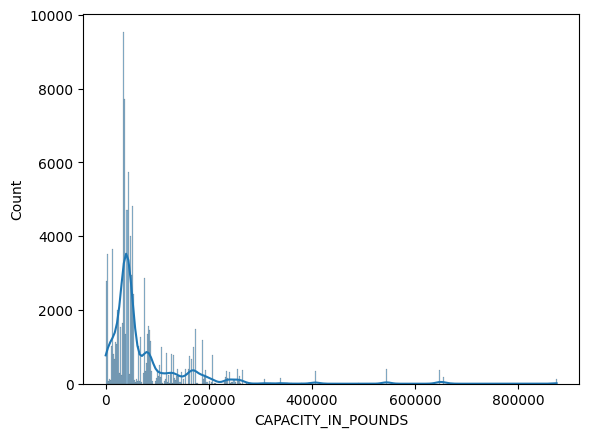

In [240]:
sns.histplot(df['CAPACITY_IN_POUNDS'], kde=True)

<Axes: xlabel='CAPACITY_IN_POUNDS_BOXCOX', ylabel='Count'>

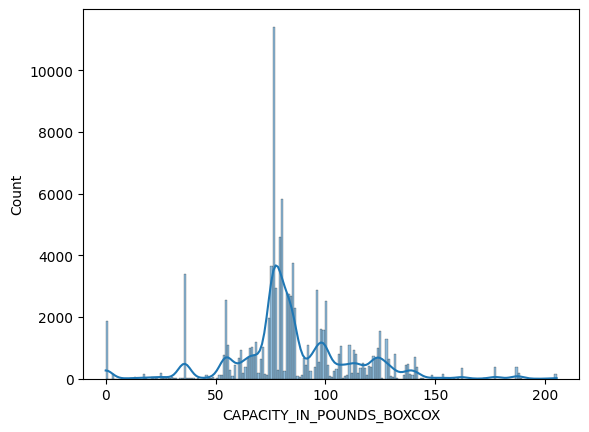

In [241]:
(df['CAPACITY_IN_POUNDS_BOXCOX'], lam) = scipy.stats.boxcox(df['CAPACITY_IN_POUNDS']+1)
sns.histplot(df['CAPACITY_IN_POUNDS_BOXCOX'], kde=True)

In [242]:
print(df['CAPACITY_IN_POUNDS'].mean())
print(df['CAPACITY_IN_POUNDS_BOXCOX'].mean())
print(df['CAPACITY_IN_POUNDS_BOXCOX'].skew())
print(lam)

71538.54827551072
84.6832101087873
0.21909784762369375
0.3030024721900964


**Problem 5**

In [243]:
df['NUMBER_OF_SEATS'].describe()

count    98145.000000
mean        96.894585
std         66.180145
min          0.000000
25%         50.000000
50%        110.000000
75%        154.000000
max        190.000000
Name: NUMBER_OF_SEATS, dtype: float64

In [244]:
df['SIZE'] = 'XLARGE'
df.loc[df['NUMBER_OF_SEATS'] <= 154, 'SIZE'] = 'LARGE'
df.loc[df['NUMBER_OF_SEATS'] <= 110, 'SIZE'] = 'MEDIUM'
df.loc[df['NUMBER_OF_SEATS'] < 50, 'SIZE'] = 'SMALL'


OPERATING_STATUS

In [245]:
print(df[df['SIZE'] == 'XLARGE']['OPERATING_STATUS'].value_counts(normalize=True))
print(df[df['SIZE'] == 'LARGE']['OPERATING_STATUS'].value_counts(normalize=True))
print(df[df['SIZE'] == 'MEDIUM']['OPERATING_STATUS'].value_counts(normalize=True))
print(df[df['SIZE'] == 'SMALL']['OPERATING_STATUS'].value_counts(normalize=True))

OPERATING_STATUS
Y    0.973039
N    0.026961
Name: proportion, dtype: float64
OPERATING_STATUS
Y    0.963302
N    0.036698
Name: proportion, dtype: float64
OPERATING_STATUS
Y    0.9442
N    0.0558
Name: proportion, dtype: float64
OPERATING_STATUS
Y    0.967522
N    0.032478
Name: proportion, dtype: float64


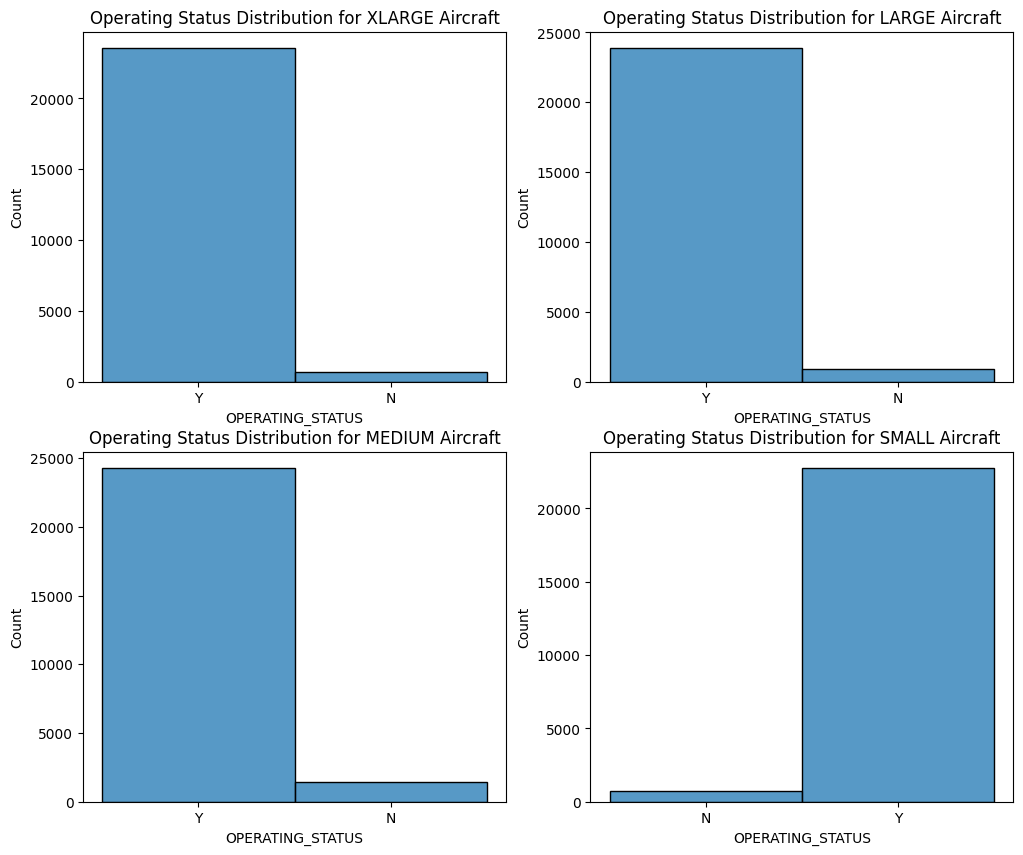

In [246]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df[df['SIZE'] == 'XLARGE']['OPERATING_STATUS'], ax=ax[0,0])
ax[0,0].set_title('Operating Status Distribution for XLARGE Aircraft')
sns.histplot(df[df['SIZE'] == 'LARGE']['OPERATING_STATUS'], ax=ax[0,1])
ax[0,1].set_title('Operating Status Distribution for LARGE Aircraft')
sns.histplot(df[df['SIZE'] == 'MEDIUM']['OPERATING_STATUS'], ax=ax[1,0])
ax[1,0].set_title('Operating Status Distribution for MEDIUM Aircraft')
sns.histplot(df[df['SIZE'] == 'SMALL']['OPERATING_STATUS'], ax=ax[1,1])
ax[1,1].set_title('Operating Status Distribution for SMALL Aircraft')
plt.show()

AIRCRAFT_STATUS

In [247]:
print(df[df['SIZE'] == 'XLARGE']['AIRCRAFT_STATUS'].value_counts(normalize=True))
print(df[df['SIZE'] == 'LARGE']['AIRCRAFT_STATUS'].value_counts(normalize=True))
print(df[df['SIZE'] == 'MEDIUM']['AIRCRAFT_STATUS'].value_counts(normalize=True))
print(df[df['SIZE'] == 'SMALL']['AIRCRAFT_STATUS'].value_counts(normalize=True))

AIRCRAFT_STATUS
O    0.691974
B    0.238804
A    0.067940
L    0.001282
Name: proportion, dtype: float64
AIRCRAFT_STATUS
O    0.641138
B    0.211829
A    0.143884
L    0.003149
Name: proportion, dtype: float64
AIRCRAFT_STATUS
B    0.552006
O    0.405308
A    0.042686
Name: proportion, dtype: float64
AIRCRAFT_STATUS
O    0.737879
B    0.213425
A    0.048653
L    0.000043
Name: proportion, dtype: float64


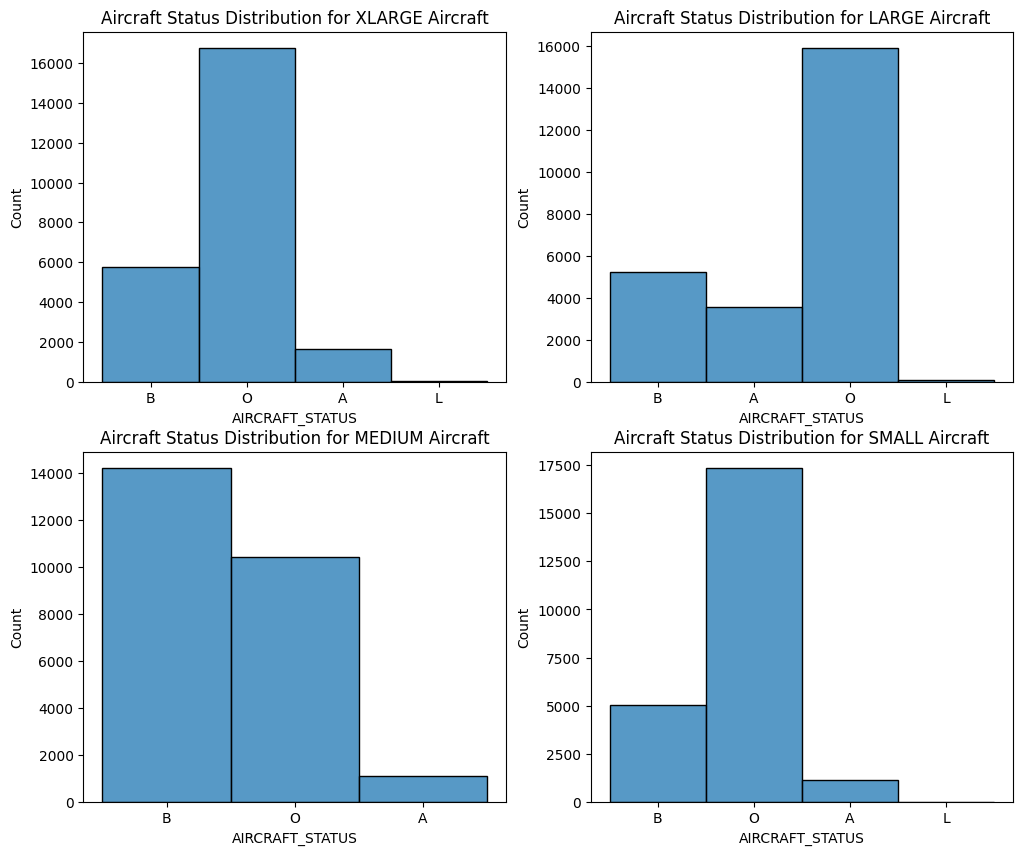

In [248]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df[df['SIZE'] == 'XLARGE']['AIRCRAFT_STATUS'], ax=ax[0,0])
ax[0,0].set_title('Aircraft Status Distribution for XLARGE Aircraft')
sns.histplot(df[df['SIZE'] == 'LARGE']['AIRCRAFT_STATUS'], ax=ax[0,1])
ax[0,1].set_title('Aircraft Status Distribution for LARGE Aircraft')
sns.histplot(df[df['SIZE'] == 'MEDIUM']['AIRCRAFT_STATUS'], ax=ax[1,0])
ax[1,0].set_title('Aircraft Status Distribution for MEDIUM Aircraft')
sns.histplot(df[df['SIZE'] == 'SMALL']['AIRCRAFT_STATUS'], ax=ax[1,1])
ax[1,1].set_title('Aircraft Status Distribution for SMALL Aircraft')
plt.show()

**Problem 6**

In [249]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [250]:
# Test-train split
numeric_df = df.select_dtypes(include='number') # only use numeric columns in models
train, test = train_test_split(numeric_df, test_size=0.2, random_state=42)
numeric_df.describe()

,YEAR,MANUFACTURE_YEAR,NUMBER_OF_SEATS,CAPACITY_IN_POUNDS,AIRLINE_ID,NUMBER_OF_SEATS_BOXCOX,CAPACITY_IN_POUNDS_BOXCOX
count,98145.000000,98145.000000,98145.000000,98145.000000,98145.000000,98145.000000,98145.000000
mean,2016.658301,2001.673453,96.894585,71538.548276,20063.479454,20.082740,84.683210
std,4.038123,44.633201,66.180145,86374.676891,392.570121,11.956894,28.195445
min,2010.000000,0.000000,0.000000,0.000000,19393.000000,0.000000,0.000000
25%,2013.000000,1997.000000,50.000000,35490.000000,19805.000000,14.949997,75.631296
50%,2017.000000,2002.000000,110.000000,43400.000000,19977.000000,24.365413,80.593081
75%,2020.000000,2009.000000,154.000000,82012.000000,20366.000000,29.893038,98.435176
max,2023.000000,2756.000000,190.000000,875000.000000,22085.000000,33.930874,205.147397


NUMBER_OF_SEATS regression model

In [251]:
X_train_seats = train.drop(columns=['NUMBER_OF_SEATS'])
y_train_seats = train['NUMBER_OF_SEATS']
X_test_seats = test.drop(columns=['NUMBER_OF_SEATS'])
y_test_seats = test['NUMBER_OF_SEATS']

seats_model = LinearRegression()
seats_model.fit(X_train_seats, y_train_seats)

seats_train_rmse = np.sqrt(mean_squared_error(y_train_seats, seats_model.predict(X_train_seats)))
seats_test_rmse = np.sqrt(mean_squared_error(y_test_seats, seats_model.predict(X_test_seats)))
print(f'RMSE for NUMBER_OF_SEATS regression model on training set: {seats_train_rmse:.2f}')
print(f'RMSE for NUMBER_OF_SEATS regression model on test set: {seats_test_rmse:.2f}')

RMSE for NUMBER_OF_SEATS regression model on training set: 11.07
RMSE for NUMBER_OF_SEATS regression model on test set: 11.05


CAPACITY_IN_POUNDS regression model

In [252]:
X_train_pounds = train.drop(columns=['CAPACITY_IN_POUNDS'])
y_train_pounds = train['CAPACITY_IN_POUNDS']
X_test_pounds = test.drop(columns=['CAPACITY_IN_POUNDS'])
y_test_pounds = test['CAPACITY_IN_POUNDS']

pounds_model = LinearRegression()
pounds_model.fit(X_train_pounds, y_train_pounds)

pounds_train_rmse = np.sqrt(mean_squared_error(y_train_pounds, pounds_model.predict(X_train_pounds)))
pounds_test_rmse = np.sqrt(mean_squared_error(y_test_pounds, pounds_model.predict(X_test_pounds)))
print(f'RMSE for CAPACITY_IN_POUNDS regression model on training set: {pounds_train_rmse:.2f}')
print(f'RMSE for CAPACITY_IN_POUNDS regression model on test set: {pounds_test_rmse:.2f}')

RMSE for CAPACITY_IN_POUNDS regression model on training set: 44220.45
RMSE for CAPACITY_IN_POUNDS regression model on test set: 43488.88


NUMBER_OF_SEATS random forest model

In [253]:
seats_rf_model = RandomForestRegressor(random_state=42)
seats_rf_model.fit(X_train_seats, y_train_seats)

seats_rf_train_rmse = np.sqrt(mean_squared_error(y_train_seats, seats_rf_model.predict(X_train_seats)))
seats_rf_test_rmse = np.sqrt(mean_squared_error(y_test_seats, seats_rf_model.predict(X_test_seats)))
print(f'RMSE for NUMBER_OF_SEATS Random Forest model on training set: {seats_rf_train_rmse:.2f}')
print(f'RMSE for NUMBER_OF_SEATS Random Forest model on test set: {seats_rf_test_rmse:.2f}')

RMSE for NUMBER_OF_SEATS Random Forest model on training set: 0.00
RMSE for NUMBER_OF_SEATS Random Forest model on test set: 0.02


CAPACITY_IN_POUNDS random forest model

In [254]:
pounds_rf_model = RandomForestRegressor(random_state=42)
pounds_rf_model.fit(X_train_pounds, y_train_pounds)

pounds_rf_train_rmse = np.sqrt(mean_squared_error(y_train_pounds, pounds_rf_model.predict(X_train_pounds)))
pounds_rf_test_rmse = np.sqrt(mean_squared_error(y_test_pounds, pounds_rf_model.predict(X_test_pounds)))
print(f'RMSE for CAPACITY_IN_POUNDS Random Forest model on training set: {pounds_rf_train_rmse:.2f}')
print(f'RMSE for CAPACITY_IN_POUNDS Random Forest model on test set: {pounds_rf_test_rmse:.2f}')

RMSE for CAPACITY_IN_POUNDS Random Forest model on training set: 30.40
RMSE for CAPACITY_IN_POUNDS Random Forest model on test set: 35.12
